In [1]:
from typing import Callable, List, Optional, Tuple, Union

import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, linregress
from sklearn.metrics.pairwise import cosine_similarity
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.optimize import OptimizeResult, minimize
from scipy.integrate import odeint as solveode
import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
def arrowed_spines(ax, columns, background="white"):
    """
    画左下角箭头的函数，引自dynamo
    """
    if type(columns) == str:
        columns = [columns.upper() + " 1", columns.upper() + " 2"]
    import matplotlib.pyplot as plt

    fig = plt.gcf()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    despline_all(ax)

    # removing the axis ticks
    deaxis_all(ax)

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length (x-axis)
    hw = 1.0 / 20.0 * (ymax - ymin)
    hl = 1.0 / 20.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.2  # arrow overhang

    # compute matching arrowhead length and width (y-axis)
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    fc, ec = ("w", "w") if background in ["black", "#ffffff"] else ("k", "k")
    ax.arrow(
        xmin,
        ymin,
        hl * 5 / 2,
        0,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=hw / 2,
        head_length=hl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )
    ax.arrow(
        xmin,
        ymin,
        0,
        hw * 5 / 2,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=yhw / 2,
        head_length=yhl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )

    ax.text(
        xmin + hl * 2.5 / 2,
        ymin - 1.5 * hw / 2,
        columns[0],
        ha="center",
        va="center",
        rotation=0,
        # size=hl * 5 / (2 * len(str(columns[0]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )
    ax.text(
        xmin - 1.5 * yhw / 2,
        ymin + hw * 2.5 / 2,
        columns[1],
        ha="center",
        va="center",
        rotation=90,
        # size=hw * 5 / (2 * len(str(columns[1]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )

    return ax

def despline_all(ax=None, sides=None):
    # removing the default axis on all sides:
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    if sides is None:
        sides = ["bottom", "right", "top", "left"]
    for side in sides:
        ax.spines[side].set_visible(False)


def deaxis_all(ax=None):
    # removing the axis ticks
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [3]:
## VAE模型
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 32,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 32,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class VAE(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 32,
        batch_norm: bool = False,
    ):
        super(VAE, self).__init__()
        self.encoder = Encoder(n_int, n_latent, n_hidden, batch_norm)
        self.decoder = Decoder(n_int, n_latent, n_hidden, batch_norm)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x, mu, log_var

In [4]:
## 读取数据
with open('data_with_phase.pickle', 'rb') as f:
    adata = pickle.load(f)
adata.shape

(8000, 45)

In [5]:
## 转换为伪时间
percentiles = np.percentile(adata[:,-1], np.linspace(0, 100, 1000))
indices = np.digitize(adata[:,-1], percentiles)
pseudotime = indices * 0.001

In [6]:
th=pseudotime
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

In [7]:
## 归一化细胞数据
np_data0 = adata[:, :-1]

np_data = (np_data0 - np_data0.min(0))/(np_data0.max(0) - np_data0.min(0))
# np_data = (np_data0 - np_data0.mean(0))/np_data0.std(0)

np_data.shape

(8000, 44)

In [8]:
tensor_data = torch.tensor(np_data, dtype=torch.float32)
data_loader = DataLoader(TensorDataset(tensor_data), batch_size=128, shuffle=True)

In [9]:
model = VAE(44)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.1)

In [10]:
# 定义损失函数
def vae_loss(reconstructed_x, x, mu, log_var):
    alpha = 0.95
    # 重构损失
    reconstruction_loss = F.mse_loss(reconstructed_x, x, reduction='sum')
    # KL 散度损失
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return alpha * reconstruction_loss + (1-alpha) * kl_divergence, reconstruction_loss, kl_divergence

In [11]:
num_epochs = 600
losses = []
losses_1 = []
losses_2 = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    loss_1 = 0.0
    loss_2 = 0.0
    for data in data_loader:
        inputs = data[0]
        
        optimizer.zero_grad()

        reconstructed_data, mean, logvar = model(inputs)
        loss, loss1, loss2 = vae_loss(reconstructed_data, inputs, mean, logvar)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        loss_1 += loss1.item()
        loss_2 += loss2.item()
    
    scheduler.step()
    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_loss_1 = loss_1 / len(data_loader.dataset)
    epoch_loss_2 = loss_2 / len(data_loader.dataset)
    losses.append(epoch_loss)
    losses_1.append(epoch_loss_1)
    losses_2.append(epoch_loss_2)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}, MSE: {epoch_loss_1}, KL:{epoch_loss_2}")

print('Finished Training')

Epoch 1/600, Loss: 7.6866746997833255, MSE: 7.853772111892701, KL:4.511825090408325
Epoch 2/600, Loss: 2.4744053163528443, MSE: 2.027971124649048, KL:10.956655319213867
Epoch 3/600, Loss: 1.7096864919662476, MSE: 1.164807147026062, KL:12.062394287109376
Epoch 4/600, Loss: 1.5244678325653076, MSE: 1.0008317832946778, KL:11.473552757263183
Epoch 5/600, Loss: 1.3880439291000366, MSE: 0.9022427453994751, KL:10.61826634979248
Epoch 6/600, Loss: 1.23924001121521, MSE: 0.7621969532966614, KL:10.303057891845704
Epoch 7/600, Loss: 1.1533447780609132, MSE: 0.7048468475341797, KL:9.674805442810058
Epoch 8/600, Loss: 1.0854410152435303, MSE: 0.6696706809997559, KL:8.985077339172364
Epoch 9/600, Loss: 1.018663809776306, MSE: 0.6383923778533935, KL:8.243820930480958
Epoch 10/600, Loss: 0.9497206268310547, MSE: 0.6087956352233886, KL:7.427295509338379
Epoch 11/600, Loss: 0.8847095975875855, MSE: 0.5784983468055725, KL:6.702723358154297
Epoch 12/600, Loss: 0.8330219359397888, MSE: 0.5586903009414673, 

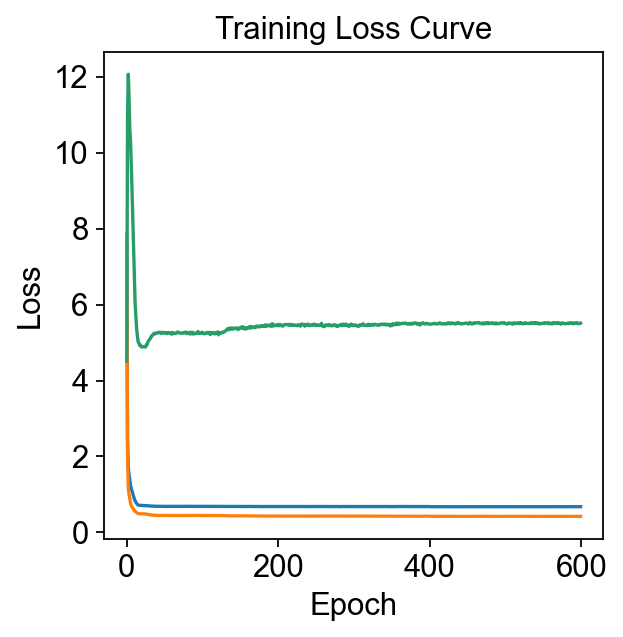

In [12]:
plt.plot(losses)
plt.plot(losses_1)
plt.plot(losses_2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

In [13]:
model.eval()
raw = torch.as_tensor(np_data, dtype=torch.float32)
latent_rep = model(raw)[1]
latent_std = torch.exp(0.5 * model(raw)[2])
reconstruct = model.decoder(latent_rep)
# reconstruct = model(raw)[0]
raw = raw.detach().numpy()
reconstruct = reconstruct.detach().numpy()
latent_rep = latent_rep.detach().numpy()
latent_std = latent_std.detach().numpy()

In [14]:
latent_std.mean(0)

array([0.9987154 , 0.99089044, 0.99716085, 0.14632106, 0.9999961 ,
       0.99980646, 1.0001317 , 1.0004889 , 0.80484706, 1.0000064 ,
       0.9994833 , 0.99899906, 0.99118614, 0.9998411 , 0.99052215,
       0.99838114, 0.31925023, 0.9984155 , 0.6060694 , 0.18635073],
      dtype=float32)

In [15]:
cwd = os.getcwd()
print("[Current working directory]:",cwd)
AE_dir = cwd+'/VAE_fit_test/'
if not os.path.exists(AE_dir):
    os.makedirs(AE_dir)

[Current working directory]: D:\ROG\desktop\振荡动力学推断结果整理\code\44dim_cell_cycle\VAE_test


In [16]:
for index in range(44):
    fig, axes = plt.subplots(1,2,figsize=(12, 5))
    sns.scatterplot(x=adata[:,-1], y=raw[:, index], alpha=0.1, ax=axes[0])
    axes[0].set_title(str(index)+'_raw')
    axes[0].set_ylabel('raw')
    axes[0].set_ylim(-0.1, 1.1)
    sns.scatterplot(x=adata[:,-1], y=reconstruct[:, index], alpha=0.1, ax=axes[1])
    axes[1].set_title(str(index)+'_reconstruct')
    axes[1].set_ylabel('reconstruct')
    axes[1].set_ylim(-0.1, 1.1)
    plt.savefig(AE_dir+str(index)+'.png')
    plt.clf()

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

...

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

<Figure size 960x400 with 0 Axes>

In [17]:
for t in range(20):
    fig, ax = plt.subplots()
    sns.scatterplot(x=adata[:,-1],y=latent_rep[:, t],alpha=0.1,ax=ax)
    ax.set_title(t)
    ax.set_ylabel('latent_rep')
    plt.savefig(AE_dir+'latent_'+str(t)+'_rep.png')
    plt.clf()
    fig, ax = plt.subplots()
    sns.scatterplot(x=adata[:,-1],y=latent_std[:, t],alpha=0.1,ax=ax)
    ax.set_title(t)
    ax.set_ylabel('latent_std')
    plt.savefig(AE_dir+'latent_'+str(t)+'_std.png')
    plt.clf()

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

...

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

In [18]:
## 对隐空间坐标标准化
latent_rep = (latent_rep - latent_rep.mean(0))/latent_rep.std(0)

In [19]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(latent_rep)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
latent_pca = (latent_rep - np.mean(latent_rep, axis=0)) @ V

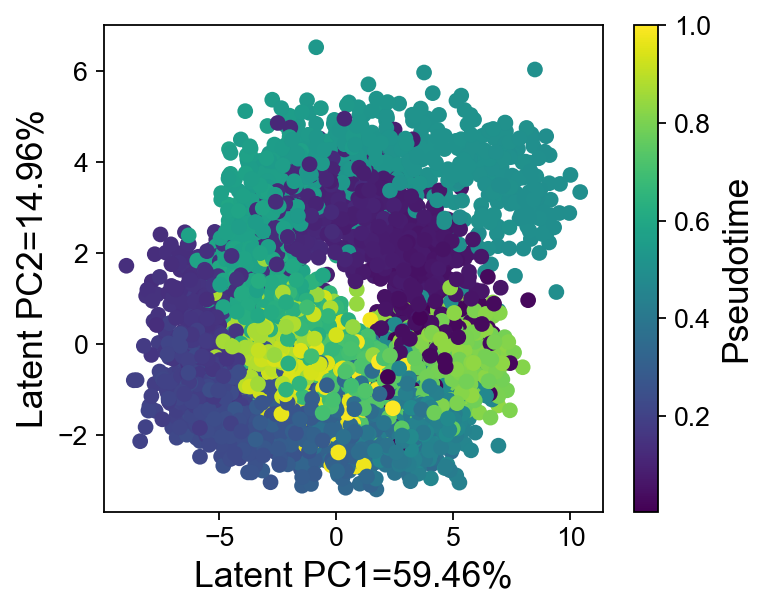

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))

sc = ax.scatter(latent_pca[:, 0], latent_pca[:, 1], c=th, 
                cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pseudotime', fontsize=16)
cbar.ax.tick_params(labelsize=12)
ax.set_xlabel(f'Latent PC1={ratio[0] * 100:.2f}%', fontsize=16)
ax.set_ylabel(f'Latent PC2={ratio[1] * 100:.2f}%', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.savefig('../figures/VAE_compare.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

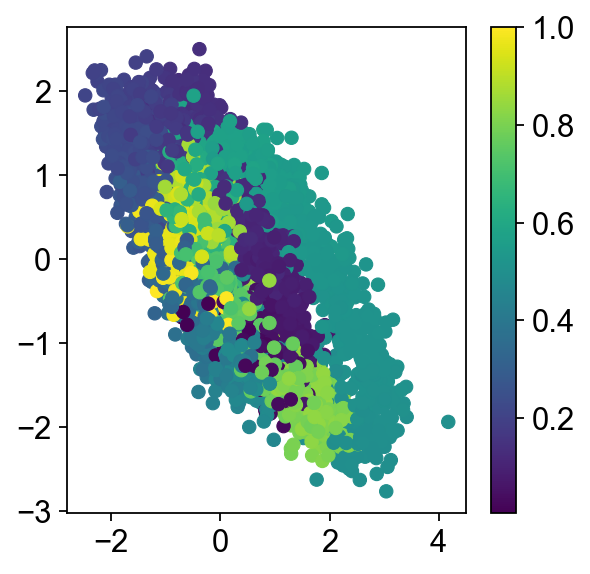

In [21]:
plt.scatter(latent_rep[:, 0], latent_rep[:, 1],c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())

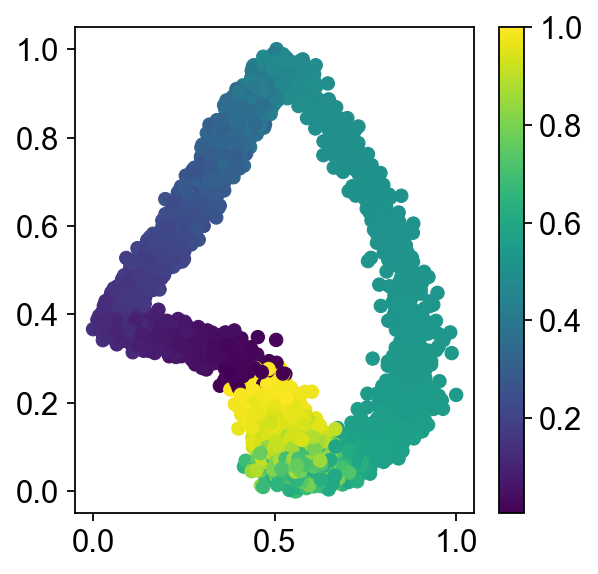

In [22]:
plt.scatter(np_data[:, 1], np_data[:, 2], c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())

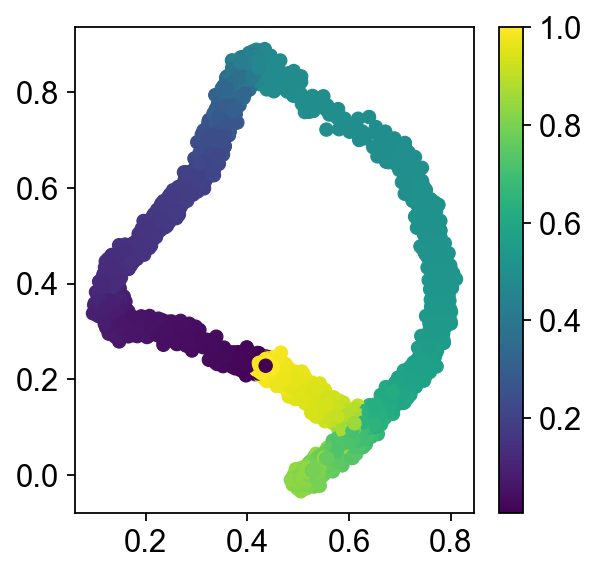

In [23]:
plt.scatter(reconstruct[:, 1], reconstruct[:, 2], c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())

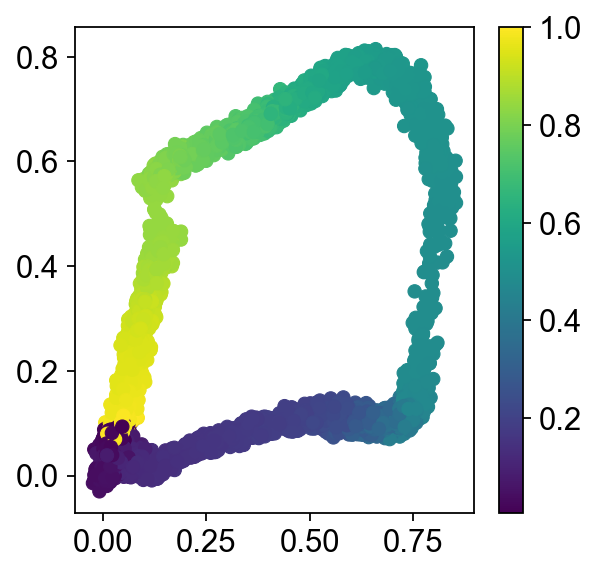

In [24]:
plt.scatter(reconstruct[:, 14], reconstruct[:, 21], c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())